# Logistic Regression Modeling for GSR Classification

This notebook develops a baseline logistic regression model for binary classification of particles labeled as `gsr` versus `non_gsr`.

The notebook includes the following steps:

1. Load and inspect the particle-level dataset
2. Clean and standardize the target labels
3. Restrict the analysis to binary labels only
4. Build feature and target matrices
5. Prevent leakage by splitting data at the `stub_id` level
6. Fit a logistic regression pipeline
7. Evaluate performance using confusion matrix, classification report, and ROC AUC
8. Visualize the ROC curve

A group-based split is used to ensure that no `stub_id` appears in both training and test data. This reduces the risk of stub-level leakage and provides a more realistic estimate of model performance.

In [11]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt

## 1. Load the Dataset

The particle-level dataset is loaded from the processed parquet file. Initial inspection is performed to confirm shape, column structure, and overall contents.

In [12]:
df = pd.read_parquet("../../../data/processed/particle_labeled.parquet")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Shape: (2801667, 95)

Columns:
['stub_id', 'particle_id', 'relevance_class', 'ac', 'ag', 'al', 'ar', 'as', 'at', 'au', 'b', 'ba', 'bi', 'br', 'ca', 'cd', 'ce', 'cl', 'co', 'cr', 'cs', 'cu', 'dy', 'er', 'eu', 'f', 'fe', 'fr', 'ga', 'gd', 'ge', 'hf', 'hg', 'ho', 'i', 'in', 'ir', 'k', 'kr', 'la', 'lu', 'mg', 'mn', 'mo', 'n', 'na', 'nb', 'nd', 'ne', 'ni', 'np', 'o', 'os', 'p', 'pa', 'pb', 'pd', 'pm', 'po', 'pr', 'pt', 'pu', 'ra', 'rb', 're', 'rh', 'rn', 'ru', 's', 'sb', 'sc', 'se', 'si', 'sm', 'sn', 'sr', 'ta', 'tb', 'tc', 'te', 'th', 'ti', 'tl', 'tm', 'u', 'v', 'w', 'xe', 'y', 'yb', 'zn', 'zr', 'merged_relevance_class', 'final_class', 'label']


,stub_id,particle_id,relevance_class,ac,ag,al,ar,as,at,au,...,v,w,xe,y,yb,zn,zr,merged_relevance_class,final_class,label
0,22,1454,PbSb,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,PbSb,PbSb,GSR
1,22,1274,PbSbBa,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,PbSbBa,PbBaSb,GSR
2,22,275,PbSbBa,0.0,0.0,0.751013,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,PbSbBa,PbBaSb,GSR
3,22,714,PbSbBa,0.0,0.0,0.824510,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,PbSbBa,PbBaSb,GSR
4,22,2887,PbSb,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,PbSb,PbSb,GSR


## 2. Inspect Low-Cardinality Columns

To better understand the structure of the data, columns with relatively few unique values are inspected. This can help identify target labels, identifiers, and metadata fields.

In [13]:
for col in df.columns:
    if df[col].nunique(dropna=False) < 10:
        print(f"\n{col}")
        print(df[col].unique())


label
<ArrowStringArray>
['GSR', 'Ambiguous', 'Non_GSR']
Length: 3, dtype: str


## 3. Clean and Standardize the Target Labels

The target column is cleaned to avoid string mismatch problems. In earlier versions of the notebook, values such as `non-gsr` and `non_gsr` were treated differently, which caused filtering issues and sometimes left only one class in the modeling dataset.

To prevent that problem, labels are converted to lowercase, stripped of extra whitespace, and standardized into a consistent naming convention.

In [14]:
target_col = "label"

df = df.dropna(subset=[target_col]).copy()

df[target_col] = (
    df[target_col]
    .astype(str)
    .str.strip()
    .str.lower()
)

df[target_col] = df[target_col].replace({
    "non-gsr": "non_gsr",
    "non gsr": "non_gsr",
    "non_gsr": "non_gsr",
    "gsr": "gsr",
    "ambiguous": "ambiguous"
})

print("Cleaned label distribution:")
print(df[target_col].value_counts(dropna=False))

print("\nUnique cleaned labels:")
print(sorted(df[target_col].dropna().unique()))

Cleaned label distribution:
label
non_gsr      1216039
gsr          1078946
ambiguous     506682
Name: count, dtype: int64

Unique cleaned labels:
['ambiguous', 'gsr', 'non_gsr']


## 4. Restrict the Dataset to Binary Classes

Logistic regression is being used here as a binary classifier, so the dataset is restricted to particles labeled `gsr` and `non_gsr`. Observations labeled `ambiguous` are excluded from this version of the model.

In [15]:
df_model = df[df[target_col].isin(["non_gsr", "gsr"])].copy()

print("Binary label distribution:")
print(df_model[target_col].value_counts(dropna=False))

Binary label distribution:
label
non_gsr    1216039
gsr        1078946
Name: count, dtype: int64


## 5. Build the Feature Matrix and Target Vector

The target variable is mapped to numeric values for modeling:

- `non_gsr` → 0
- `gsr` → 1

To reduce leakage, identifier fields such as `stub_id` and `particle_id` are excluded from the predictor matrix. The `stub_id` field is retained separately so it can be used for grouped train/test splitting.

In [16]:
if "stub_id" not in df_model.columns:
    raise ValueError("stub_id column is missing. It is required for grouped splitting.")

groups = df_model["stub_id"]

drop_cols = [target_col]
for col in ["stub_id", "particle_id"]:
    if col in df_model.columns:
        drop_cols.append(col)

X = df_model.drop(columns=drop_cols)
X = X.select_dtypes(include=[np.number])

y = df_model[target_col].map({
    "non_gsr": 0,
    "gsr": 1
})

print("X shape:", X.shape)
print("\nMapped target distribution:")
print(y.value_counts(dropna=False))
print("\nUnique y values:", sorted(y.dropna().unique()))
print("NaNs in y:", y.isna().sum())

X shape: (2294985, 89)

Mapped target distribution:
label
0    1216039
1    1078946
Name: count, dtype: int64

Unique y values: [np.int64(0), np.int64(1)]
NaNs in y: 0


## 6. Validate the Modeling Data

Before splitting the data, validation checks are performed to ensure that:

- the filtered modeling dataset is not empty
- the target vector contains no missing values
- both target classes are present

These checks help catch label-cleaning issues before model training begins.

In [17]:
if df_model.empty:
    raise ValueError("df_model is empty after filtering for non_gsr and gsr.")

if y.isna().any():
    raise ValueError("y contains NaN values after mapping. Check label values above.")

if y.nunique() < 2:
    raise ValueError(
        f"y contains fewer than 2 classes after cleaning. Found classes: {sorted(y.dropna().unique())}"
    )

## 7. Split the Data by `stub_id`

A standard row-level random split can lead to leakage if particles from the same `stub_id` appear in both the training and test sets. Because particles from the same stub may share similar characteristics, that type of split can artificially inflate performance.

To reduce this risk, the train/test split is performed using `GroupShuffleSplit`, with `stub_id` as the grouping variable. This ensures that each stub appears entirely in either the training set or the test set, but never both.

In [18]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("y_train distribution:")
print(y_train.value_counts())

print("\ny_test distribution:")
print(y_test.value_counts())

y_train distribution:
label
0    982764
1    868997
Name: count, dtype: int64

y_test distribution:
label
0    233275
1    209949
Name: count, dtype: int64


## 8. Confirm That There Is No Stub Overlap

A verification step is included to confirm that no `stub_id` appears in both the training and test sets. If overlap is found, the notebook raises an error.

In [19]:
train_stubs = set(groups_train)
test_stubs = set(groups_test)
overlap = train_stubs.intersection(test_stubs)

print("Number of train stubs:", len(train_stubs))
print("Number of test stubs:", len(test_stubs))
print("Number of overlapping stubs:", len(overlap))

if len(overlap) > 0:
    raise ValueError("Stub leakage detected: some stub_id values appear in both train and test.")

Number of train stubs: 3028
Number of test stubs: 758
Number of overlapping stubs: 0


## 9. Build the Logistic Regression Pipeline

A simple preprocessing and modeling pipeline is used:

- missing numeric values are imputed using the median
- predictors are standardized
- logistic regression is fit to the processed training data

This provides a baseline binary classification model for comparison with future modeling approaches.

In [20]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

## 10. Fit the Model

The logistic regression pipeline is fit using the grouped training data.

In [21]:
pipeline.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


## 11. Generate Predictions and Evaluate Performance

Model performance is evaluated on the held-out test set using:

- confusion matrix
- classification report
- ROC AUC

These metrics provide an initial view of binary classification performance after leakage control has been applied.

In [22]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC AUC:", roc_auc_score(y_test, y_prob))

Confusion Matrix:
[[232745    530]
 [  3462 206487]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    233275
           1       1.00      0.98      0.99    209949

    accuracy                           0.99    443224
   macro avg       0.99      0.99      0.99    443224
weighted avg       0.99      0.99      0.99    443224


ROC AUC: 0.9992621645095504


## 12. Plot the ROC Curve

The ROC curve is plotted to visualize the tradeoff between true positive rate and false positive rate across classification thresholds.

If the ROC curve still appears unrealistically perfect after grouped splitting, additional leakage sources should be investigated, such as identifier-like predictors or derived variables that may encode class information too directly.

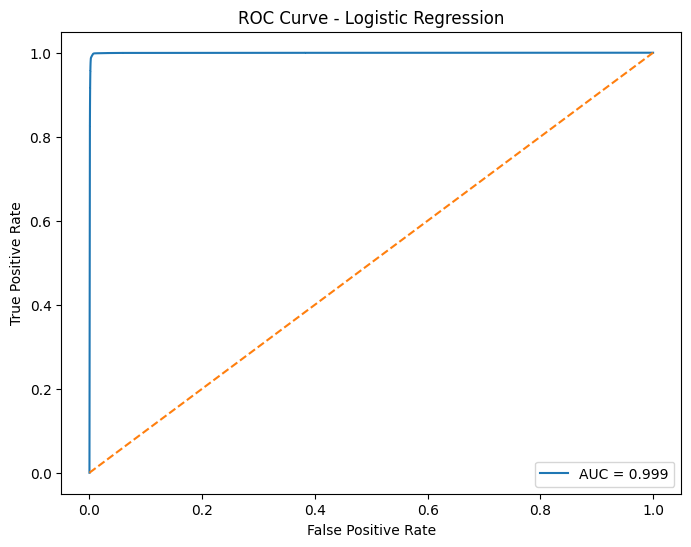

In [23]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

## 13. Debugging Checks

If the model still produces suspiciously strong results or raises class-balance errors, the following diagnostic checks can be used to inspect:

- cleaned label counts
- mapped target counts
- number of unique stubs
- feature columns included in the model

In [24]:
print("Cleaned label distribution:")
print(df[target_col].value_counts(dropna=False))

print("\nBinary label distribution:")
print(df_model[target_col].value_counts(dropna=False))

print("\nMapped y distribution:")
print(y.value_counts(dropna=False))

print("\nUnique y values:")
print(sorted(y.dropna().unique()))

print("\nNumber of unique stubs:")
print(df_model["stub_id"].nunique())

print("\nFeature columns:")
print(X.columns.tolist())

Cleaned label distribution:
label
non_gsr      1216039
gsr          1078946
ambiguous     506682
Name: count, dtype: int64

Binary label distribution:
label
non_gsr    1216039
gsr        1078946
Name: count, dtype: int64

Mapped y distribution:
label
0    1216039
1    1078946
Name: count, dtype: int64

Unique y values:
[np.int64(0), np.int64(1)]

Number of unique stubs:
3786

Feature columns:
['ac', 'ag', 'al', 'ar', 'as', 'at', 'au', 'b', 'ba', 'bi', 'br', 'ca', 'cd', 'ce', 'cl', 'co', 'cr', 'cs', 'cu', 'dy', 'er', 'eu', 'f', 'fe', 'fr', 'ga', 'gd', 'ge', 'hf', 'hg', 'ho', 'i', 'in', 'ir', 'k', 'kr', 'la', 'lu', 'mg', 'mn', 'mo', 'n', 'na', 'nb', 'nd', 'ne', 'ni', 'np', 'o', 'os', 'p', 'pa', 'pb', 'pd', 'pm', 'po', 'pr', 'pt', 'pu', 'ra', 'rb', 're', 'rh', 'rn', 'ru', 's', 'sb', 'sc', 'se', 'si', 'sm', 'sn', 'sr', 'ta', 'tb', 'tc', 'te', 'th', 'ti', 'tl', 'tm', 'u', 'v', 'w', 'xe', 'y', 'yb', 'zn', 'zr']


## Summary

This notebook created a baseline logistic regression model for binary GSR classification while addressing two important methodological issues:

1. target-label string mismatches were corrected through label standardization
2. train/test leakage was reduced by splitting the data at the `stub_id` level

This approach provides a more realistic performance estimate and creates a stronger foundation for later model comparisons.